# 07. Tree Models, Random Forests, and Gradient Boosting

Linear models are powerful, fast, and often surprisingly competitive. But many operational problems are not primarily linear. They depend on thresholds, rule-like interactions, and regime changes: a service queue becomes dangerous only when backlog crosses a limit, incidents spike during release periods, and high-touch customers behave differently once case complexity passes a certain point. Those are exactly the settings in which tree models become natural workhorses.

This notebook studies three layers of the tree-model family. First, we use a shallow regression tree to understand CART-style recursive partitioning. Second, we show why a single deep tree can become unstable even when its training error looks impressive. Third, we move to ensembles: random forests reduce variance by averaging many decorrelated trees, while gradient boosting improves performance by fitting later trees to the remaining errors of earlier ones.

The analytical theme is not "trees are better than linear models." The real lesson is narrower and more useful: when the signal is rule-like and interaction-heavy, tree-based models often match the data-generating structure more naturally than a global linear approximation. The notebook follows classic references on tree induction (Quinlan, 1986), bagging (Breiman, 1996), random forests (Breiman, 2001), and gradient boosting (Friedman, 2001).

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain how a regression tree partitions the feature space into rule-defined regions.
2. Distinguish among a shallow interpretable tree, a deeper unstable tree, a random forest, and a boosting model.
3. Diagnose when tree depth helps and when it mainly increases variance.
4. Explain why bagging and random forests stabilize noisy tree predictors.
5. Describe gradient boosting as iterative error correction rather than just "more trees."
6. Use feature importance and partial-dependence tools carefully when interpreting tree ensembles.


## 1. Why Tree-Based Models Matter

Tree models are attractive in operational machine learning because they naturally encode the kinds of conditions analysts often describe verbally.

| Modeling situation | Why trees fit it well |
|---|---|
| Threshold effects | Splits explicitly create rules such as `backlog_ratio > 0.62` |
| Interactions | Later splits can make the effect of one variable depend on another |
| Mixed feature types | Numeric and categorical predictors can coexist after light preprocessing |
| Heterogeneous subpopulations | Leaves can represent different operating regimes without forcing one global slope |
| Operational communication | A shallow tree can often be explained as a sequence of decision rules |

But trees also have weaknesses. A single tree can have high variance, meaning small changes in the training sample can produce meaningfully different structures and predictions. Ensemble methods exist partly to solve that problem.


### Mathematical Spine: Recursive Partitions, Impurity Reduction, and Ensemble Averaging

A regression tree represents a prediction rule as a partition of feature space into regions \(R_1, \ldots, R_M\), with a constant prediction inside each region:

$$
T(x) = \sum_{m=1}^M c_m \, \mathbf{1}[x \in R_m].
$$

For squared-error regression, the fitted value in each terminal region is the region mean. A candidate split on feature \(j\) at threshold \(s\) creates two child regions,

$$
R_1(j,s) = \{x : x_j \le s\}, \qquad R_2(j,s) = \{x : x_j > s\},
$$

and CART chooses the split that minimizes within-node squared error:

$$
\min_{j,s}
\left[
\sum_{x_i \in R_1(j,s)} (y_i - \bar y_{R_1})^2
+
\sum_{x_i \in R_2(j,s)} (y_i - \bar y_{R_2})^2
\right].
$$

For classification trees, the same recursive logic is often expressed with impurity measures such as the Gini index or entropy. If a node has class probabilities \(p_1, \ldots, p_K\), then common impurity scores are

$$
\operatorname{Gini}(p) = 1 - \sum_{k=1}^K p_k^2,
$$

and

$$
H(p) = -\sum_{k=1}^K p_k \log p_k.
$$

Single trees are interpretable but unstable. Random forests reduce variance by averaging many decorrelated trees:

$$
\hat f_{\text{RF}}(x) = \frac{1}{B} \sum_{b=1}^B T_b(x).
$$

The averaging lowers sensitivity to any one noisy split, which is why forests are usually more stable than a single deep tree.

Gradient boosting takes a different route. It builds an additive predictor

$$
f_M(x) = \sum_{m=0}^M \nu h_m(x),
$$

where each new tree \(h_m\) is fit to the remaining errors or negative gradients of the current model. For differentiable loss \(L\), the working target at stage \(m\) is often written as

$$
r_i^{(m)} = -\left.\frac{\partial L(y_i, f(x_i))}{\partial f(x_i)}\right|_{f = f_{m-1}}.
$$

So the three main ideas in this notebook are mathematically distinct: single trees partition the space, random forests average unstable partitions, and boosting builds a stagewise additive correction sequence.

In [1]:
# Section focus: Mathematical Spine: Recursive Partitions, Impurity Reduction, and Ensemble Averaging.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from IPython.display import Image, display
from graphviz import Source
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, export_graphviz, export_text

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", None)


In [2]:
# Section focus: Mathematical Spine: Recursive Partitions, Impurity Reduction, and Ensemble Averaging.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def make_one_hot_encoder(drop=None):
    """Construct the one hot encoder helper used in the 07. Tree Models, Random Forests, and Gradient Boosting workflow.
    
    Parameters
    ----------
    drop : object
        The drop setting that controls the one hot encoder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)


def rmse(y_true, y_pred):
    """Compute root mean squared error for the prediction task in this lecture.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the rmse calculation.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_regression(y_true, y_pred):
    """Evaluate regression for the 07. Tree Models, Random Forests, and Gradient Boosting decision workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r_squared": float(r2_score(y_true, y_pred)),
    }


def simulate_tree_friendly_support_data(n_accounts=520, n_months=12, random_state=2026):
    """Create a simulated tree friendly support data set for the 07. Tree Models, Random Forests, and Gradient Boosting case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    n_months : object
        Count or size setting for the tree friendly support data calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    regions = np.array(["North America", "Europe", "APAC", "LATAM"])
    tiers = np.array(["Basic", "Growth", "Premium", "Strategic"])
    industries = np.array(["SaaS", "FinTech", "Healthcare", "Manufacturing"])

    rows = []
    for account_number in range(1, n_accounts + 1):
        region = rng.choice(regions, p=[0.38, 0.24, 0.23, 0.15])
        tier = rng.choice(tiers, p=[0.24, 0.35, 0.28, 0.13])
        industry = rng.choice(industries)

        account_complexity = rng.normal(0, 1)
        sponsor_strength = rng.normal(0, 1)
        base_usage = rng.beta(4, 2)
        active_seats = np.exp(
            rng.normal(
                3.9 + 0.25 * (tier == "Premium") + 0.55 * (tier == "Strategic"),
                0.35,
            )
        )

        for month in range(1, n_months + 1):
            release_shock = int(month >= 9)

            usage_ratio = np.clip(
                base_usage
                + 0.10 * sponsor_strength
                - 0.08 * account_complexity
                - 0.09 * release_shock
                + rng.normal(0, 0.08),
                0.03,
                0.99,
            )
            adoption_breadth = np.clip(
                1
                / (1 + np.exp(-(0.2 + 1.15 * usage_ratio + 0.35 * sponsor_strength - 0.35 * account_complexity + rng.normal(0, 0.7)))),
                0.02,
                0.99,
            )
            backlog_ratio = np.clip(
                0.38
                + 0.18 * account_complexity
                - 0.12 * sponsor_strength
                + 0.11 * release_shock
                + rng.normal(0, 0.10),
                0.01,
                0.99,
            )
            critical_incidents_30d = int(
                max(
                    0,
                    rng.poisson(np.exp(-1.35 + 1.10 * account_complexity + 0.85 * backlog_ratio + 0.35 * release_shock)),
                )
            )
            avg_response_hours_30d = np.exp(
                0.90
                + 0.24 * account_complexity
                - 0.14 * sponsor_strength
                + 0.60 * backlog_ratio
                + 0.14 * release_shock
                + rng.normal(0, 0.18)
            )
            prior_escalation_rate = np.clip(
                0.11
                + 0.10 * account_complexity
                - 0.08 * sponsor_strength
                + 0.04 * (month > 4)
                + rng.normal(0, 0.05),
                0,
                1,
            )
            csat_score = np.clip(
                0.77
                + 0.10 * sponsor_strength
                - 0.15 * backlog_ratio
                - 0.10 * release_shock
                + rng.normal(0, 0.05),
                0.05,
                0.99,
            )
            ticket_queue_depth = 18 * backlog_ratio + 0.9 * critical_incidents_30d + rng.normal(0, 1.2)
            unresolved_bug_flags = max(0, critical_incidents_30d + rng.normal(0, 1.0))
            high_priority_case_mix = np.clip(0.28 + 0.22 * account_complexity + 0.08 * release_shock + rng.normal(0, 0.04), 0, 1)
            sponsor_engagement = np.clip(0.66 + 0.17 * sponsor_strength - 0.08 * backlog_ratio + rng.normal(0, 0.04), 0, 1)
            weekend_activity = np.clip(0.15 + 0.11 * usage_ratio + rng.normal(0, 0.05), 0, 1)
            duplicate_backlog = backlog_ratio + rng.normal(0, 0.015)
            duplicate_response = avg_response_hours_30d + rng.normal(0, 0.25)

            nonlinear_component = (
                16 * ((backlog_ratio > 0.62) and (critical_incidents_30d >= 2))
                + 9 * (release_shock and (avg_response_hours_30d > 7.0))
                + 8 * ((usage_ratio < 0.42) and (csat_score < 0.68))
                + 7 * ((tier == "Strategic") and (backlog_ratio > 0.55))
                + 6 * ((region == "LATAM") and (weekend_activity > 0.22))
                + 5 * ((high_priority_case_mix > 0.55) and (unresolved_bug_flags >= 3))
                - 4 * ((usage_ratio > 0.72) and (sponsor_engagement > 0.74))
            )

            support_hours_next_month = (
                12
                + 0.035 * active_seats
                + 5.0 * backlog_ratio
                + 0.9 * critical_incidents_30d
                + 0.7 * avg_response_hours_30d
                + 1.5 * (1 - csat_score)
                + 1.5 * max(account_complexity, 0)
                + 1.5 * (tier == "Premium")
                + 2.5 * (tier == "Strategic")
                + nonlinear_component
                + rng.normal(0, 5.0)
            )

            rows.append(
                {
                    "account_id": f"A{account_number:04d}",
                    "month": month,
                    "region": region,
                    "tier": tier,
                    "industry": industry,
                    "active_seats": active_seats,
                    "usage_ratio": usage_ratio,
                    "adoption_breadth": adoption_breadth,
                    "backlog_ratio": backlog_ratio,
                    "critical_incidents_30d": critical_incidents_30d,
                    "avg_response_hours_30d": avg_response_hours_30d,
                    "prior_escalation_rate": prior_escalation_rate,
                    "csat_score": csat_score,
                    "ticket_queue_depth": ticket_queue_depth,
                    "unresolved_bug_flags": unresolved_bug_flags,
                    "high_priority_case_mix": high_priority_case_mix,
                    "sponsor_engagement": sponsor_engagement,
                    "weekend_activity": weekend_activity,
                    "duplicate_backlog": duplicate_backlog,
                    "duplicate_response": duplicate_response,
                    "release_shock": release_shock,
                    "support_hours_next_month": support_hours_next_month,
                }
            )

    return pd.DataFrame(rows)


def build_ridge_preprocessor(numeric_features, categorical_features):
    """Build the ridge preprocessor object used in the 07. Tree Models, Random Forests, and Gradient Boosting analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the ridge preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_one_hot_encoder(drop="first")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def build_tree_preprocessor(numeric_features, categorical_features):
    """Build the tree preprocessor object used in the 07. Tree Models, Random Forests, and Gradient Boosting analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the tree preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_one_hot_encoder(drop="first")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def render_tree_png(fitted_tree, feature_names, *, width=1200):
    """Render tree png for display in the 07. Tree Models, Random Forests, and Gradient Boosting notebook.
    
    Parameters
    ----------
    fitted_tree : object
        The fitted tree setting that controls the tree png calculation in this notebook.
    feature_names : object
        Column or variable name used to select information from the input table.
    width : object
        Display setting used to make the plot or table readable in the rendered notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the tree png calculation and reused by later cells.
    """
    dot_data = export_graphviz(
        fitted_tree,
        out_file=None,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        impurity=False,
        proportion=False,
        precision=2,
    )
    graph = Source(dot_data)
    return Image(graph.pipe(format="png"), width=width)


## 2. Synthetic Nonlinear Service-Operations Data

We will work with a synthetic support-forecasting problem designed to reward rule-based modeling. The outcome is **next-month support hours**, and the data-generating process includes explicit threshold interactions such as:

- high backlog becoming especially costly once incidents are already elevated,
- release-shock periods becoming risky only when response times are also slow,
- low usage and low satisfaction combining into a higher-burden regime.

These interactions are still plausible in business operations, but they are not naturally linear. That makes the dataset a good test bed for tree models.


,quantity,value
0,Rows,6240.000000
1,Training rows,3640.000000
2,Validation rows,1040.000000
3,Test rows,1560.000000
4,Original numeric features,16.000000
5,Share in high backlog + incident regime,0.116000
6,Mean support hours,25.530000


,regime,mean_support_hours,rows
0,Backlog <= 0.62 or incidents < 2,21.730000,5515
1,Backlog > 0.62 and incidents >= 2,54.443000,725


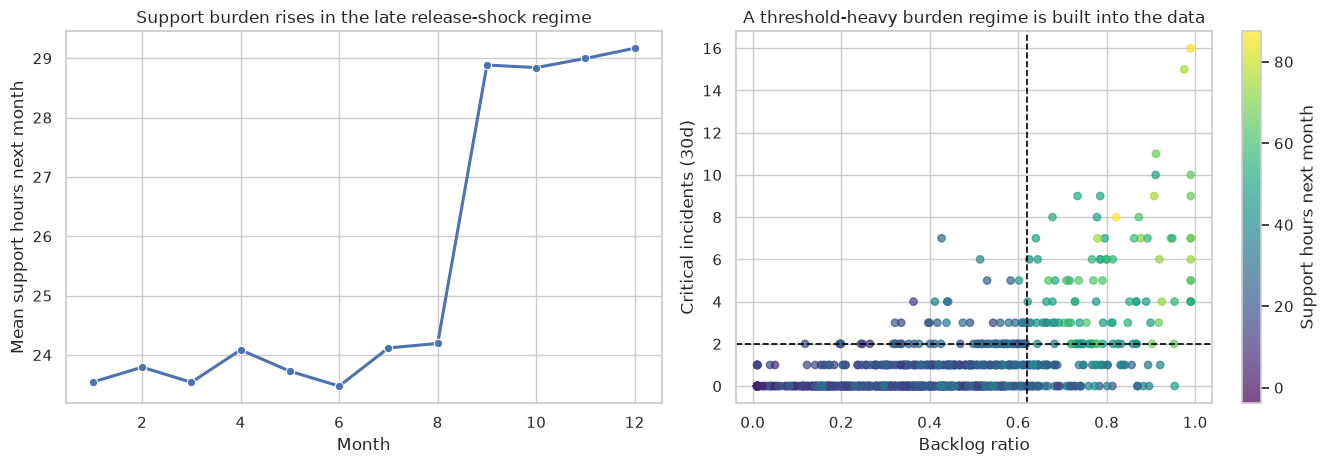

In [3]:
# Section focus: 2. Synthetic Nonlinear Service-Operations Data.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


df = simulate_tree_friendly_support_data()
train = df[df["month"] <= 7].copy()
validation = df[df["month"].isin([8, 9])].copy()
test = df[df["month"] >= 10].copy()

categorical_features = ["region", "tier", "industry"]
numeric_features = [
    column
    for column in df.columns
    if column not in categorical_features + ["account_id", "month", "support_hours_next_month"]
]

high_backlog_incident_regime = (
    (df["backlog_ratio"] > 0.62) & (df["critical_incidents_30d"] >= 2)
)

overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": len(df)},
        {"quantity": "Training rows", "value": len(train)},
        {"quantity": "Validation rows", "value": len(validation)},
        {"quantity": "Test rows", "value": len(test)},
        {"quantity": "Original numeric features", "value": len(numeric_features)},
        {
            "quantity": "Share in high backlog + incident regime",
            "value": round(high_backlog_incident_regime.mean(), 3),
        },
        {"quantity": "Mean support hours", "value": round(df["support_hours_next_month"].mean(), 2)},
    ]
)

monthly_summary = df.groupby("month", as_index=False).agg(mean_support_hours=("support_hours_next_month", "mean"))
regime_summary = pd.DataFrame(
    {
        "regime": ["Backlog <= 0.62 or incidents < 2", "Backlog > 0.62 and incidents >= 2"],
        "mean_support_hours": [
            df.loc[~high_backlog_incident_regime, "support_hours_next_month"].mean(),
            df.loc[high_backlog_incident_regime, "support_hours_next_month"].mean(),
        ],
        "rows": [int((~high_backlog_incident_regime).sum()), int(high_backlog_incident_regime.sum())],
    }
)

smart_display(overview)
smart_display(regime_summary.round(3))

sample_for_scatter = df.sample(n=900, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8))

sns.lineplot(data=monthly_summary, x="month", y="mean_support_hours", marker="o", linewidth=2.2, ax=axes[0])
axes[0].set_title("Support burden rises in the late release-shock regime")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean support hours next month")

scatter = axes[1].scatter(
    sample_for_scatter["backlog_ratio"],
    sample_for_scatter["critical_incidents_30d"],
    c=sample_for_scatter["support_hours_next_month"],
    cmap="viridis",
    alpha=0.70,
    s=28,
)
axes[1].axvline(0.62, color="black", linestyle="--", linewidth=1.2)
axes[1].axhline(2.0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_title("A threshold-heavy burden regime is built into the data")
axes[1].set_xlabel("Backlog ratio")
axes[1].set_ylabel("Critical incidents (30d)")
plt.colorbar(scatter, ax=axes[1], label="Support hours next month")

plt.tight_layout()
plt.show()


The threshold lines in the second panel are not arbitrary decorations. They are clues about the data-generating structure. Once backlog moves past a certain level *and* incidents are already elevated, support burden tends to jump. A global linear model can approximate this pattern, but a tree can represent it directly as a split-and-refine rule system.


## 3. CART Intuition with a Shallow Regression Tree

A regression tree works by recursively partitioning the feature space. At each internal node, the algorithm selects a split that reduces residual variation as much as possible. Each terminal node then predicts a constant value, usually the mean of the training outcomes that fall into that leaf.

For teaching purposes, we first fit a small tree to a focused set of six numeric features. That keeps the structure readable while still allowing the model to discover the important threshold logic.


|--- backlog_ratio <= 0.64
|   |--- backlog_ratio <= 0.36
|   |   |--- avg_response_hours_30d <= 2.12
|   |   |   |--- value: [16.02]
|   |   |--- avg_response_hours_30d >  2.12
|   |   |   |--- value: [19.24]
|   |--- backlog_ratio >  0.36
|   |   |--- critical_incidents_30d <= 1.50
|   |   |   |--- value: [22.64]
|   |   |--- critical_incidents_30d >  1.50
|   |   |   |--- value: [28.41]
|--- backlog_ratio >  0.64
|   |--- critical_incidents_30d <= 1.50
|   |   |--- usage_ratio <= 0.42
|   |   |   |--- value: [34.57]
|   |   |--- usage_ratio >  0.42
|   |   |   |--- value: [25.79]
|   |--- critical_incidents_30d >  1.50
|   |   |--- critical_incidents_30d <= 3.50
|   |   |   |--- value: [47.30]
|   |   |--- critical_incidents_30d >  3.50
|   |   |   |--- value: [56.40]



,split,rmse,mae,r_squared
0,Train,6.430,5.053,0.681
1,Validation,7.634,5.948,0.709
2,Test,8.273,6.286,0.719


,leaf_id,rows,mean_support_hours,mean_backlog_ratio,mean_incidents,mean_usage_ratio,mean_csat_score
7,14,147,56.404,0.816,6.401,0.483,0.606
6,13,165,47.299,0.748,2.424,0.519,0.581
4,10,62,34.566,0.747,0.532,0.253,0.497
3,7,243,28.407,0.519,2.675,0.581,0.719
5,11,154,25.795,0.742,0.539,0.607,0.559
2,6,1216,22.639,0.477,0.338,0.609,0.671
1,4,1039,19.238,0.250,0.302,0.701,0.755
0,3,614,16.021,0.124,0.116,0.771,0.804


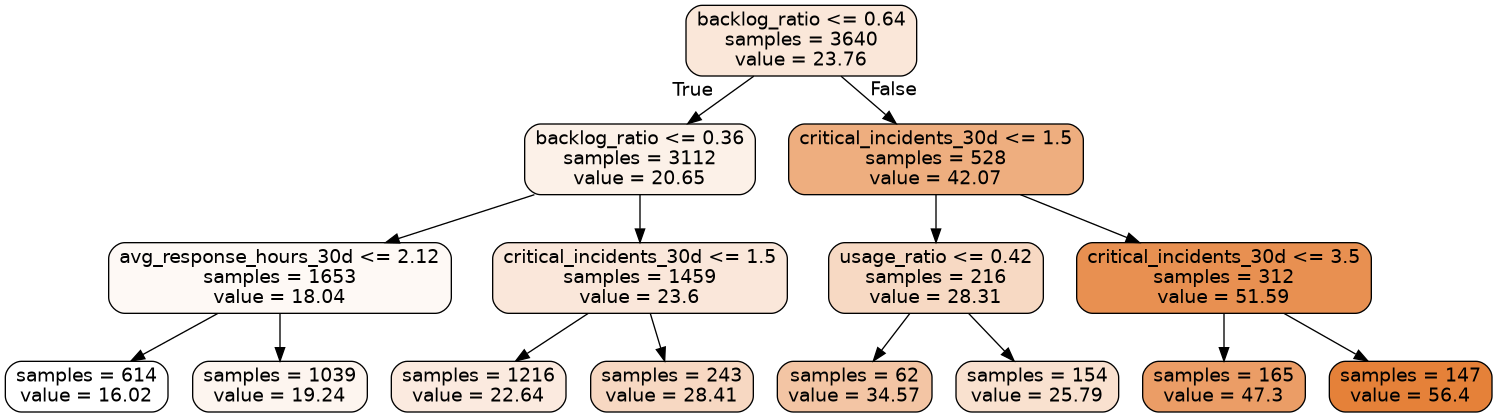

In [4]:
# Section focus: 3. CART Intuition with a Shallow Regression Tree.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


core_tree_features = [
    "backlog_ratio",
    "critical_incidents_30d",
    "avg_response_hours_30d",
    "usage_ratio",
    "csat_score",
    "release_shock",
]

shallow_core_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=35, random_state=0)
shallow_core_tree.fit(train[core_tree_features], train["support_hours_next_month"])

leaf_ids = shallow_core_tree.apply(train[core_tree_features])
leaf_summary = (
    train.assign(leaf_id=leaf_ids)
    .groupby("leaf_id", as_index=False)
    .agg(
        rows=("support_hours_next_month", "size"),
        mean_support_hours=("support_hours_next_month", "mean"),
        mean_backlog_ratio=("backlog_ratio", "mean"),
        mean_incidents=("critical_incidents_30d", "mean"),
        mean_usage_ratio=("usage_ratio", "mean"),
        mean_csat_score=("csat_score", "mean"),
    )
    .sort_values("mean_support_hours", ascending=False)
)

shallow_tree_metrics = []
for split_name, frame in [("Train", train), ("Validation", validation), ("Test", test)]:
    predictions = shallow_core_tree.predict(frame[core_tree_features])
    shallow_tree_metrics.append({"split": split_name, **evaluate_regression(frame["support_hours_next_month"], predictions)})
shallow_tree_metrics = pd.DataFrame(shallow_tree_metrics)

print(export_text(shallow_core_tree, feature_names=core_tree_features))
smart_display(shallow_tree_metrics.round(3))
smart_display(leaf_summary.round(3))
display(render_tree_png(shallow_core_tree, core_tree_features, width=1100))


In CART Intuition with a Shallow Regression Tree, the point of the output is practical. The output should reduce ambiguity around the next operational choice.


### Discussion of the Shallow Tree

The shallow tree already captures the main operational logic. In this fit it splits primarily on backlog pressure, critical incidents, response time, and usage intensity. That is exactly the kind of rule structure practitioners often describe in plain language: when queue pressure is high and operational frictions accumulate, next-month support demand rises quickly.

This is also a good reminder that tree structure is data-dependent. Even though we offered the model variables such as satisfaction and release-shock status, the best shallow partition for this training window did not need them. That does not make those variables unimportant in general; it means that for this sample and depth budget, the strongest early splits came from the more immediate operational bottlenecks.

But interpretability comes with a cost. The small tree is readable, yet it leaves meaningful residual error on the table. We should think of it as the interpretable entry point for the model family, with comparison against stronger predictors still required.


## 4. From Single Trees to Ensembles

We now compare five models on the full feature set:

1. a ridge baseline,
2. a shallow regression tree,
3. a deeper regression tree,
4. a random forest,
5. a histogram-based gradient boosting model.

This comparison separates three issues that are easy to conflate:

- **model form**: linear vs tree-based,
- **tree complexity**: shallow vs deep,
- **ensemble strategy**: averaging many trees vs sequentially correcting errors.


,model,split,rmse,mae,r_squared
0,Ridge,Train,6.429,5.037,0.681
1,Ridge,Validation,7.487,5.785,0.720
2,Ridge,Test,7.765,6.014,0.753
3,Tree depth 3,Train,6.568,5.183,0.667
4,Tree depth 3,Validation,7.583,5.876,0.713
5,Tree depth 3,Test,8.467,6.466,0.706
6,Tree deep,Train,1.480,1.014,0.983
7,Tree deep,Validation,8.050,6.402,0.676
8,Tree deep,Test,8.374,6.556,0.712
9,Random forest,Train,4.490,3.491,0.844


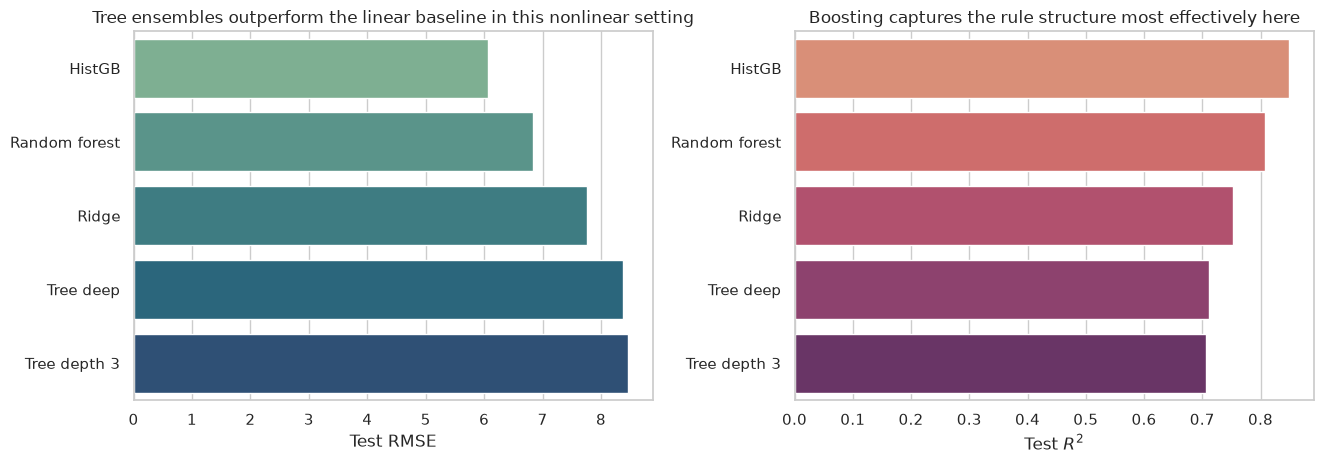

In [5]:
# Section focus: 4. From Single Trees to Ensembles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


ridge_preprocessor = build_ridge_preprocessor(numeric_features, categorical_features)
tree_preprocessor = build_tree_preprocessor(numeric_features, categorical_features)

model_specs = {
    "Ridge": Pipeline(
        steps=[
            ("preprocessor", ridge_preprocessor),
            ("model", Ridge(alpha=3.0)),
        ]
    ),
    "Tree depth 3": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeRegressor(max_depth=3, min_samples_leaf=35, random_state=0)),
        ]
    ),
    "Tree deep": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeRegressor(max_depth=None, min_samples_leaf=2, random_state=0)),
        ]
    ),
    "Random forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=400,
                    min_samples_leaf=8,
                    max_features="sqrt",
                    random_state=0,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "HistGB": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_depth=4,
                    learning_rate=0.05,
                    max_iter=200,
                    min_samples_leaf=20,
                    random_state=0,
                ),
            ),
        ]
    ),
}

fitted_models = {}
comparison_rows = []
for model_name, pipeline in model_specs.items():
    pipeline.fit(train[categorical_features + numeric_features], train["support_hours_next_month"])
    fitted_models[model_name] = pipeline

    for split_name, frame in [("Train", train), ("Validation", validation), ("Test", test)]:
        predictions = pipeline.predict(frame[categorical_features + numeric_features])
        comparison_rows.append(
            {
                "model": model_name,
                "split": split_name,
                **evaluate_regression(frame["support_hours_next_month"], predictions),
            }
        )

comparison = pd.DataFrame(comparison_rows)
test_comparison = comparison[comparison["split"] == "Test"].sort_values("rmse").reset_index(drop=True)

smart_display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

sns.barplot(data=test_comparison, x="rmse", y="model", palette="crest", ax=axes[0])
axes[0].set_title("Tree ensembles outperform the linear baseline in this nonlinear setting")
axes[0].set_xlabel("Test RMSE")
axes[0].set_ylabel("")

sns.barplot(data=test_comparison, x="r_squared", y="model", palette="flare", ax=axes[1])
axes[1].set_title("Boosting captures the rule structure most effectively here")
axes[1].set_xlabel("Test $R^2$")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


From Single Trees to Ensembles gives a checkpoint for the decision workflow. Read the result through the next choice it would change.


,depth,train_rmse,validation_rmse
0,2,7.210,8.473
1,3,6.567,7.572
2,4,6.063,7.045
3,5,5.694,6.733
4,6,5.367,6.566
5,8,4.911,6.576
6,10,4.592,6.734
7,None,4.261,6.865


,iteration,validation_rmse
134,135.000,5.786


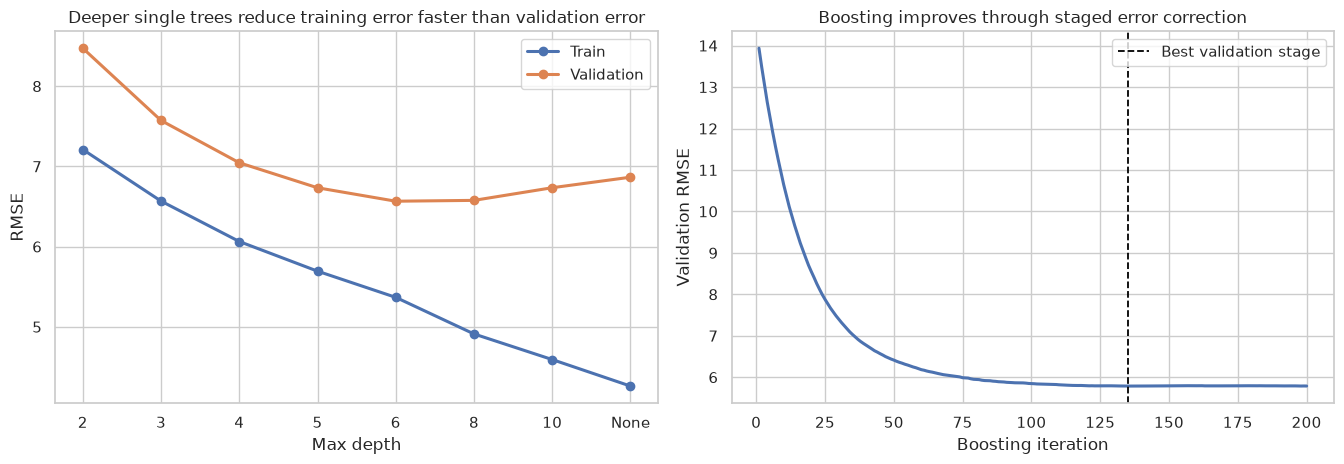

In [6]:
# Section focus: 4. From Single Trees to Ensembles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


depth_rows = []
for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    depth_model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeRegressor(max_depth=depth, min_samples_leaf=10, random_state=0)),
        ]
    )
    depth_model.fit(train[categorical_features + numeric_features], train["support_hours_next_month"])
    depth_rows.append(
        {
            "depth": "None" if depth is None else depth,
            "train_rmse": rmse(train["support_hours_next_month"], depth_model.predict(train[categorical_features + numeric_features])),
            "validation_rmse": rmse(validation["support_hours_next_month"], depth_model.predict(validation[categorical_features + numeric_features])),
        }
    )

depth_results = pd.DataFrame(depth_rows)

# Fit the boosting model without the pipeline wrapper so that staged predictions are available directly.
encoded_train = tree_preprocessor.fit_transform(train[categorical_features + numeric_features])
encoded_validation = tree_preprocessor.transform(validation[categorical_features + numeric_features])
boosting_staged_model = HistGradientBoostingRegressor(
    max_depth=4,
    learning_rate=0.05,
    max_iter=200,
    min_samples_leaf=20,
    random_state=0,
)
boosting_staged_model.fit(encoded_train, train["support_hours_next_month"])

staged_rows = []
for stage_index, staged_predictions in enumerate(boosting_staged_model.staged_predict(encoded_validation), start=1):
    staged_rows.append(
        {
            "iteration": stage_index,
            "validation_rmse": rmse(validation["support_hours_next_month"], staged_predictions),
        }
    )
staged_results = pd.DataFrame(staged_rows)
best_stage = staged_results.loc[staged_results["validation_rmse"].idxmin()]

smart_display(depth_results.round(3))
smart_display(pd.DataFrame([best_stage]).round(3))

depth_plot = depth_results.copy()
depth_plot["depth_label"] = depth_plot["depth"].astype(str)
depth_positions = np.arange(len(depth_plot))

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8))

axes[0].plot(depth_positions, depth_plot["train_rmse"], marker="o", linewidth=2.2, label="Train")
axes[0].plot(depth_positions, depth_plot["validation_rmse"], marker="o", linewidth=2.2, label="Validation")
axes[0].set_xticks(depth_positions)
axes[0].set_xticklabels(depth_plot["depth_label"])
axes[0].set_title("Deeper single trees reduce training error faster than validation error")
axes[0].set_xlabel("Max depth")
axes[0].set_ylabel("RMSE")
axes[0].legend()

sns.lineplot(data=staged_results, x="iteration", y="validation_rmse", linewidth=2.2, ax=axes[1])
axes[1].axvline(best_stage["iteration"], color="black", linestyle="--", linewidth=1.3, label="Best validation stage")
axes[1].set_title("Boosting improves through staged error correction")
axes[1].set_xlabel("Boosting iteration")
axes[1].set_ylabel("Validation RMSE")
axes[1].legend()

plt.tight_layout()
plt.show()


At this point, the score has to become an operating choice. The useful reading is which metric would change the action in From Single Trees to Ensembles. When metrics conflict, ask which error the organization can least afford.


### Discussion of the Model Comparison

The single-tree story is now clear. A shallow tree is readable but underfits. A deeper tree fits training data dramatically better, yet its validation and test advantages are limited because variance rises quickly. Random forests improve over a single tree by averaging many decorrelated trees. Gradient boosting goes one step further here because it is well matched to the structured residual patterns left behind by earlier trees.

The depth curve and the staged boosting curve teach complementary lessons. Tree depth controls model flexibility *within one tree*. Boosting iterations control how much sequential correction we allow *across many small trees*. Both are bias-variance dials, but they act in different ways.


## 5. Bagging and Variance Reduction

Breiman's bagging idea is simple: if individual trees are noisy but informative, averaging them can preserve much of the signal while cancelling some of the variance. Random forests strengthen that logic by injecting feature-level randomness, which helps keep trees from becoming too correlated with one another.

To make that concrete, we refit a deep single tree and a random forest across bootstrap-resampled training sets and compare their predictions for one difficult high-burden account.


,account_id,month,region,tier,industry,support_hours_next_month
670,A0056,11,LATAM,Growth,Manufacturing,77.591


,model,mean_prediction,prediction_std,min_prediction,max_prediction
0,Deep tree,65.334,5.912,57.183,73.883
1,Random forest,61.631,1.652,56.877,65.283


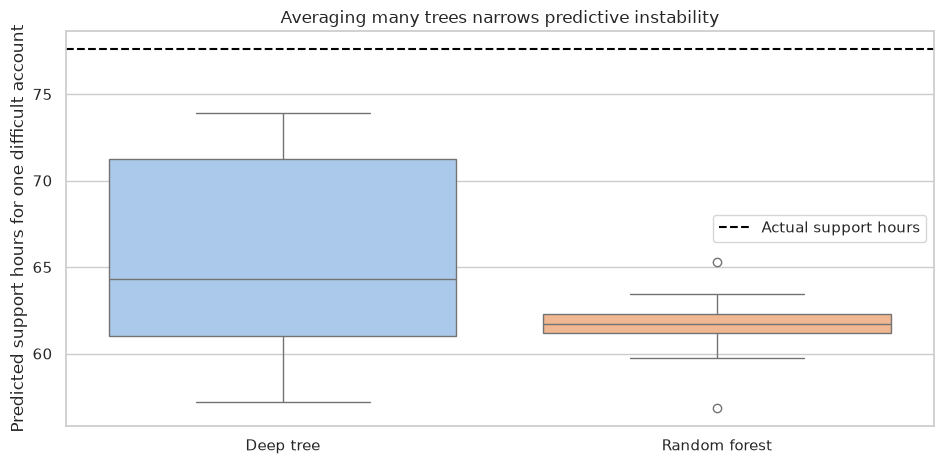

In [7]:
# Section focus: 5. Bagging and Variance Reduction.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


reference_case = (
    test.sort_values("support_hours_next_month", ascending=False)
    .iloc[[15]][["account_id", "month", "region", "tier", "industry", "support_hours_next_month"] + numeric_features]
)
reference_overview = reference_case[["account_id", "month", "region", "tier", "industry", "support_hours_next_month"]]

bootstrap_predictions = []
for bootstrap_index in range(20):
    sampled_train = train.sample(frac=1, replace=True, random_state=200 + bootstrap_index)

    deep_tree_bootstrap = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeRegressor(max_depth=None, min_samples_leaf=2, random_state=0)),
        ]
    )
    forest_bootstrap = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=8,
                    max_features="sqrt",
                    random_state=0,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    deep_tree_bootstrap.fit(sampled_train[categorical_features + numeric_features], sampled_train["support_hours_next_month"])
    forest_bootstrap.fit(sampled_train[categorical_features + numeric_features], sampled_train["support_hours_next_month"])

    bootstrap_predictions.append(
        {"model": "Deep tree", "predicted_support_hours": deep_tree_bootstrap.predict(reference_case[categorical_features + numeric_features])[0]}
    )
    bootstrap_predictions.append(
        {"model": "Random forest", "predicted_support_hours": forest_bootstrap.predict(reference_case[categorical_features + numeric_features])[0]}
    )

bootstrap_predictions = pd.DataFrame(bootstrap_predictions)
bootstrap_summary = (
    bootstrap_predictions.groupby("model", as_index=False)
    .agg(
        mean_prediction=("predicted_support_hours", "mean"),
        prediction_std=("predicted_support_hours", "std"),
        min_prediction=("predicted_support_hours", "min"),
        max_prediction=("predicted_support_hours", "max"),
    )
)

smart_display(reference_overview)
smart_display(bootstrap_summary.round(3))

fig, ax = plt.subplots(figsize=(9.6, 4.8))
sns.boxplot(data=bootstrap_predictions, x="model", y="predicted_support_hours", palette="pastel", ax=ax)
ax.axhline(reference_case["support_hours_next_month"].iloc[0], color="black", linestyle="--", linewidth=1.5, label="Actual support hours")
ax.set_title("Averaging many trees narrows predictive instability")
ax.set_xlabel("")
ax.set_ylabel("Predicted support hours for one difficult account")
ax.legend()
plt.tight_layout()
plt.show()


The Bagging and Variance Reduction result matters when it changes the next move. Use the result to decide whether the model or the operating policy needs adjustment.


### Discussion of Bagging

The bootstrap boxplot makes the variance story concrete. The deep tree can swing widely across resampled training sets because a few altered splits change the structure substantially. The random forest is not perfect, but it is far more stable because each prediction is already an average over many trees.

This is why random forests are so useful in tabular practice. They often deliver a strong default blend of flexibility, stability, and modest tuning burden.


## 6. Interpreting Tree Ensembles Carefully

Interpretation becomes trickier once we leave the single-tree world. Tree ensembles are usually not summarized faithfully by one set of slopes or one neat diagram. Instead, we rely on tools such as permutation importance and partial dependence.

These tools are useful, but they answer limited questions:

- permutation importance asks how much predictive performance falls when one feature is disrupted,
- partial dependence shows how predictions change on average as one feature moves while others are averaged out.

Neither tool is a causal estimator, and both can be influenced by correlated proxies.


,feature,importance,importance_std
0,critical_incidents_30d,5.224,0.123
1,backlog_ratio,3.750,0.106
2,usage_ratio,1.699,0.055
3,ticket_queue_depth,1.429,0.061
4,avg_response_hours_30d,0.490,0.027
5,unresolved_bug_flags,0.440,0.026
6,tier,0.397,0.033
7,csat_score,0.310,0.044
8,high_priority_case_mix,0.307,0.022
9,duplicate_response,0.204,0.013


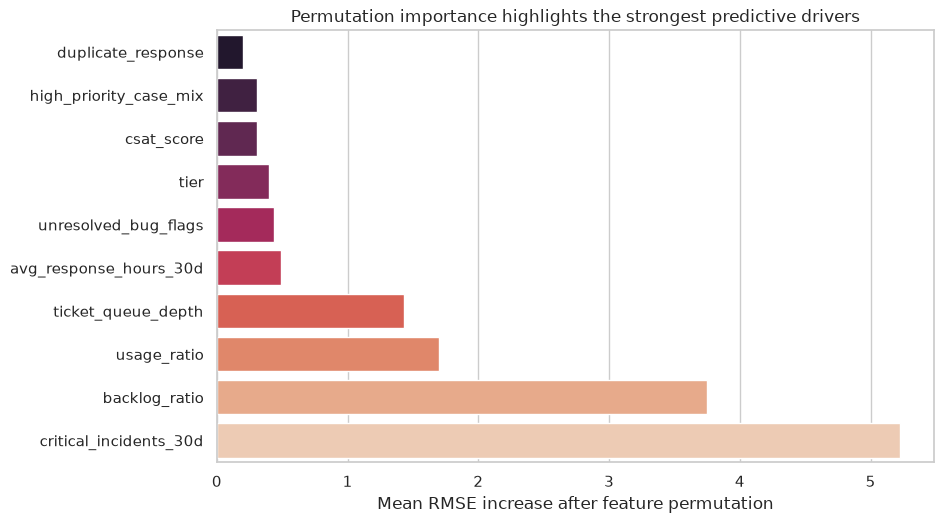

In [8]:
# Section focus: 6. Interpreting Tree Ensembles Carefully.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


permutation = permutation_importance(
    fitted_models["HistGB"],
    test[categorical_features + numeric_features],
    test["support_hours_next_month"],
    n_repeats=10,
    random_state=0,
    scoring="neg_root_mean_squared_error",
)

importance_table = (
    pd.DataFrame(
        {
            "feature": categorical_features + numeric_features,
            "importance": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

smart_display(importance_table.head(12).round(3))

fig, ax = plt.subplots(figsize=(9.6, 5.4))
sns.barplot(data=importance_table.head(10).sort_values("importance"), x="importance", y="feature", palette="rocket", ax=ax)
ax.set_title("Permutation importance highlights the strongest predictive drivers")
ax.set_xlabel("Mean RMSE increase after feature permutation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Read Interpreting Tree Ensembles Carefully as a decision checkpoint. Use the pattern to choose the next model check or operating rule.


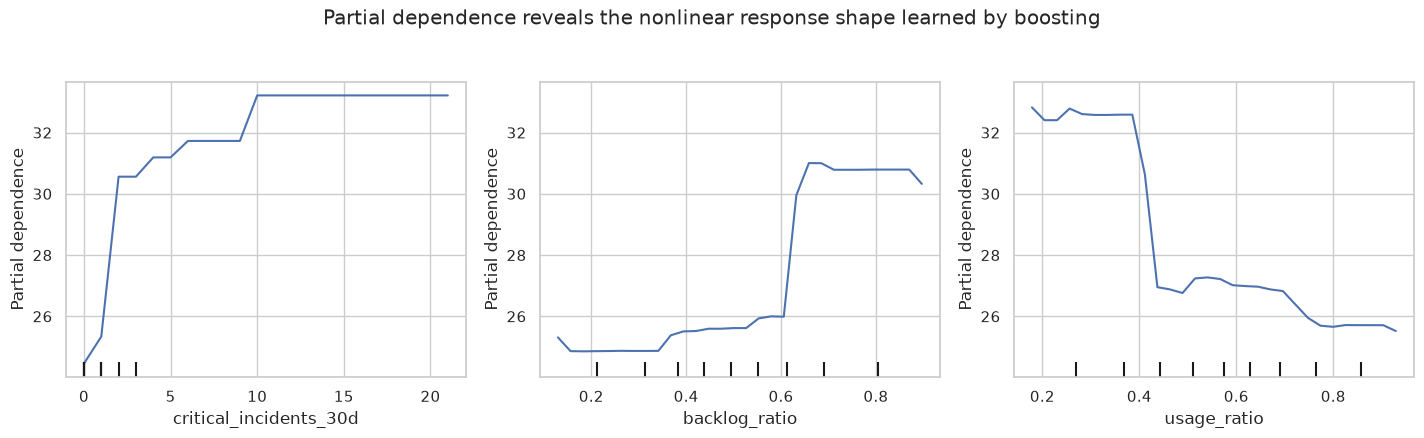

In [9]:

pdp_frame = test[categorical_features + numeric_features].copy()
for feature in ["critical_incidents_30d", "release_shock"]:
    pdp_frame[feature] = pdp_frame[feature].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.2))
PartialDependenceDisplay.from_estimator(
    fitted_models["HistGB"],
    pdp_frame,
    ["critical_incidents_30d", "backlog_ratio", "usage_ratio"],
    grid_resolution=30,
    ax=axes,
)
fig.suptitle("Partial dependence reveals the nonlinear response shape learned by boosting", y=1.04)
plt.tight_layout()
plt.show()


The practical question in Interpreting Tree Ensembles Carefully is simple. What would this result make the analyst do differently?


### Discussion of Interpretation

The importance ranking is broadly sensible: incidents, queue depth, backlog, usage, and response time all matter. But notice the familiar caution sign: correlated proxies such as `backlog_ratio` and `duplicate_backlog` can both appear useful, and the field-level importance for `tier` does not tell us which internal one-hot split carried the signal.

The partial-dependence plots are more behaviorally informative. They show that the fitted boosting model has learned nonlinearity rather than a smooth straight-line effect. That is exactly the modeling advantage we expected from trees in this setting. Still, these plots remain descriptive summaries of the fitted predictor, not causal response curves.


## 7. Practical Checklist

| Question | Why it matters |
|---|---|
| Does the problem appear threshold-heavy or interaction-heavy? | Tree models are most valuable when rule structure matters |
| Is interpretability a first-order requirement? | A shallow tree may be useful even when an ensemble predicts better |
| Is one deep tree unstable across sample perturbations? | That is a strong signal to consider bagging or random forests |
| Are we tuning depth and number of boosting iterations on validation data? | Both are bias-variance controls |
| Are ensemble interpretation tools being described as predictive rather than causal? | Importance and dependence plots do not identify interventions |
| Are correlated proxies crowding the feature set? | Importance rankings can fragment across duplicate signals |
| Is the model improvement large enough to justify extra monitoring complexity? | Tree ensembles are powerful, but they should still earn their operational footprint |

A tree ensemble is a strong choice when the data-generating structure is genuinely nonlinear. It is not a universal default, and its flexibility should still be governed with the same validation discipline we use elsewhere.


## Wrap-Up

This notebook showed why tree-based methods are central tools for tabular decision support. A shallow regression tree translated threshold structure into readable rules. A deeper tree gained flexibility but also became unstable. Random forests reduced that variance through averaging, and gradient boosting performed best here because it could keep refining the residual structure left by earlier trees.

Just as importantly, the notebook showed what these models do *not* give us for free. Ensembles are harder to summarize than a single tree, and importance-style interpretation needs restraint when features are correlated. The right lesson is not "use boosting for everything." It is: when the signal is regime-based, threshold-driven, and interaction-heavy, tree ensembles often match the problem better than a global linear approximation.

## References

- Quinlan, J. R. (1986). *Induction of decision trees.* *Machine Learning, 1*(1), 81-106. [https://doi.org/10.1007/BF00116251](https://doi.org/10.1007/BF00116251)
- Breiman, L. (1996). *Bagging Predictors.* *Machine Learning, 24*(2), 123-140. [https://doi.org/10.1023/A:1018054314350](https://doi.org/10.1023/A:1018054314350)
- Breiman, L. (2001). *Random Forests.* *Machine Learning, 45*(1), 5-32. [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)
- Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine.* *The Annals of Statistics, 29*(5). [https://doi.org/10.1214/aos/1013203451](https://doi.org/10.1214/aos/1013203451)
